# Data Exploration Challenge — Welltory COVID-19 & Wearables Dataset

**Author:** *Kuba Romanczuk*

This notebook explores a subset of the [Welltory COVID-19 and Wearables Open Data Research](https://github.com/Welltory/hrv-covid19) dataset.


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

For this excercise I'm choosing 2 data sets - data/participants.csv and data/hrv_measurements.csv. The reason is that patient is the most basic table - it tells us about sampling, data context, who participated in the research, etc, while hrv_measurements have data that is a core of the research, i.e. there's also info about sleep which is extendend in the different dataset. 

From original datatypes.md:**data/participants.csv**

Contains general information about users (participants)

|     |            |                            |           |
|-----|------------|----------------------------|-----------|
|     | **Column** | **Description**            | **Units** |
| 0   | user\_code | Unique user ID             |           |
| 1   | gender     | Gender: m/f/other or empty |           |
| 2   | age\_range | Age range                  |           |
| 3   | city       | City                       |           |
| 4   | country    | Country                    |           |
| 5   | height     | Height                     | cm        |
| 6   | weight     | Weight                     | kg        |
| 7   | symptoms_onset | The onset date of the symptoms of the disease. The format is MM/DD/YYYY. |    |

**data/hrv_measurements.csv**

Contains data based on heart rate variability (HRV) measurements collected from COVID-19 participants via the Welltory app

|     |               |                                                                                         |                  |
|-----|---------------|-----------------------------------------------------------------------------------------|------------------|
|     | **Column**    | **Description**                                                                         | **Units**        |
| 0   | user\_code    | Unique user ID                                                                          |                  |
| 1   | rr\_code      | Unique measurement ID                                                                   |                  |
| 2   | measurement\_datetime  | Measurement datetime in YYYY-MM-DD hh:mm:ss format                             |                  |
| 3   | time\_of\_day | Time of day: 'evening', 'morning', 'night' or 'day'                                     |                  |
| 4   | bpm           | Heart rate during measurement                                                           | beats per minute |
| 5   | meanrr        | Mean RR — average time between each heartbeat.                                          | milliseconds     |
| 6   | mxdmn         | MxDMn — the difference between highest and lowest cardio interval values.               | seconds          |
| 7   | sdnn          | SDNN — standard deviation of normal heartbeat intervals.                                | milliseconds     |
| 8   | rmssd         | rMSSD — root mean square of successive differences for consecutive intervals.           | milliseconds     |
| 9   | pnn50         | PNN50 — percent of RR-intervals that fall outside a 50 ms range of the average.         | %                |
| 10  | mode          | Moda — the most common cardio interval length in a measurement.                         | milliseconds     |
| 11  | amo           | AMo50 — mode amplitude.                                                                 | %/50milliseconds |
| 12  | lf            | LF — the power of low frequency waves.                                                  | milliseconds²    |
| 13  | hf            | HF — the power of high frequency waves.                                                 | milliseconds²    |
| 14  | vlf           | VLF — power of very low frequency waves.                                                | milliseconds²    |
| 15  | lfhf          | LF/HF — ratio of low to high frequency waves.                                           |                  |
| 16  | total\_power  | Total Power — the total power of HF, LF, and VLF waves generated by the heart.          | milliseconds²    |
| 17  | how\_feel     | Health score — answers to "How do you feel physically?" in the post-measurement survey. |                  |
| 18  | how\_mood     | Mood score — answers to "How is your mood?" in the post-measurement survey.             |                  |
| 19  | how\_sleep    | Sleep score —answers to "How did you sleep?" in the post-measurement survey.            |                  |
| 20  | rr\_data      | Intervals in milliseconds between consecutive heart beats as a comma-separated string   |                  |
| 21  | tags          | Tags assigned by user as a comma-separated string                                       |



In [8]:
participants = pd.read_csv('participants.csv')
print("Data Structure")
print("---------------")
print(f"Dimensions: {participants.shape}")
print(f"Data Types:\n{participants.dtypes}")
print(f"Missing Values:\n{participants.isnull().sum()}")
display(participants.head())

hrv = pd.read_csv("hrv_measurements.csv")
print("Data Structure")
print("---------------")
print(f"Dimensions: {hrv.shape}")
print(f"Data Types:\n{hrv.dtypes}")
print(f"Missing Values:\n{hrv.isnull().sum()}")
display(hrv.head())


# sns.histplot(data=df, x="age")

Data Structure
---------------
Dimensions: (185, 8)
Data Types:
user_code             str
gender                str
age_range             str
city                  str
country               str
height            float64
weight            float64
symptoms_onset        str
dtype: object
Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


Data Structure
---------------
Dimensions: (3245, 22)
Data Types:
user_code                   str
rr_code                     str
measurement_datetime        str
time_of_day                 str
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
how_sleep               float64
tags                        str
rr_data                     str
dtype: object
Missing Values:
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                     

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,...,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,...,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,...,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,...,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,...,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


<Axes: xlabel='age_range', ylabel='count'>

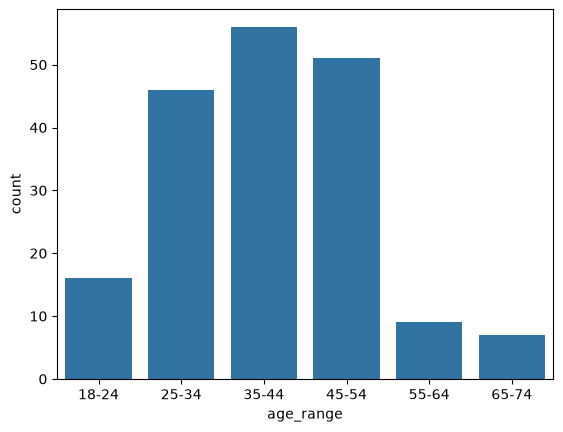

In [9]:
# sns.histplot(data=df_participants, x="age_range")
# 1. Define your desired order explicitly
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]


sns.countplot(
    data=participants, 
    x="age_range", 
    order=age_order, 
)


Data is based on users who tracked there their health via an APP. As expected, the dataset contains mostly data for people in range of 25-54 as they are probably most intrested in their health and also are profficient with technology. This is a huge limitation as COVID was the most dangerous for older people who are highly unrepresented in the dataset. 

## 2. What the Features Mean

From the dataset's own [`datatypes.md`](https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md):

**`hrv_measurements.csv`** (one row = one HRV measurement):
| Column | Meaning | Units |
|---|---|---|
| `bpm` | heart rate during measurement | bpm |
| `meanrr` | average time between heartbeats | ms |
| `sdnn` | standard deviation of heartbeat intervals — overall HRV | ms |
| `rmssd` | root mean square of successive interval differences — short-term HRV | ms |
| `pnn50` | % of intervals differing by >50ms from the mean | % |
| `lf`, `hf`, `vlf` | power in low/high/very-low frequency bands of the HRV signal | ms² |
| `lfhf` | ratio of LF to HF power — often used as a stress/autonomic-balance proxy | — |
| `total_power` | sum of LF+HF+VLF power | ms² |
| `how_feel`, `how_mood`, `how_sleep` | self-reported Likert scale, **-2 (very bad) to +2 (very good)** | — |
| `time_of_day` | when the measurement was taken | — |


**🧠 Your turn:** `lfhf` is described by researchers as an autonomic nervous system "stress" indicator. In 1-2 sentences, what would you *expect* to see if COVID symptom severity genuinely affects autonomic stress response — i.e. what pattern would confirm or challenge that idea in this data?

*(write your answer here)*


### Data structure

Checking data structure by Merging `hrv_measurements` with `participants` on `user_code` 

In [10]:
df = hrv.merge(participants, on="user_code", how="left")
print("Merged shape:", df.shape)
df.info()


Merged shape: (3245, 29)
<class 'pandas.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   str    
 1   rr_code               3245 non-null   str    
 2   measurement_datetime  3245 non-null   str    
 3   time_of_day           3245 non-null   str    
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf   

In [11]:
df.head(3)

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,...,how_sleep,tags,rr_data,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.9,0.12,45.802,54.174,15.15,...,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8...",m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.0,0.11,32.889,33.022,16.16,...,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83...",m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.1,0.17,54.811,65.987,17.17,...,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73...",f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020


Looks like the structure is correct, there are no types that should be changed


### Descriptive Statistics


In [12]:
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = ["bpm","meanrr","sdnn","rmssd","pnn50","lf","hf","vlf","lfhf","total_power"]
desc = df[numeric_columns].describe().T
print("Central Tendency Measures:")
print(desc[['mean', '50%']])
print("\nDispersion Measures:")
print(desc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df[numeric_columns].skew())
print(df[numeric_columns].kurt())



Descriptive Statistics
----------------------
Central Tendency Measures:
                    mean       50%
bpm            73.257935    72.000
meanrr        839.600366   829.100
sdnn           52.489218    46.919
rmssd          52.814196    42.869
pnn50          20.615609    16.160
lf            927.038213   423.000
hf           1125.041294   380.000
vlf           578.229892   293.000
lfhf            2.397769     0.862
total_power  2630.309399  1387.000

Dispersion Measures:
                     std      min        max
bpm            12.201088   44.000    125.000
meanrr        137.420367  477.730   1346.740
sdnn           29.369506    9.515    206.631
rmssd          39.353213    6.340    310.800
pnn50          18.588156    0.000     91.920
lf           1455.424089    2.000  15522.000
hf           2490.540413    4.000  33490.000
vlf           876.679652    1.000  18468.000
lfhf            5.750760    0.032    105.625
total_power  3912.247496   44.000  41118.000

Distribution Measures:


We can see the highest difference between mean and 50% for all of the frequency waves related fields (LF,HF, VLF, LF/HF)


### Data Quality Checks

Checking, in order: duplicates, missing values (and *whether* missingness looks random), and domain-implausible values.


In [13]:
# --- Duplicates ---
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate (user_code, measurement_datetime) pairs:", 
      df.duplicated(subset=["user_code","measurement_datetime"]).sum())


Exact duplicate rows: 0
Duplicate (user_code, measurement_datetime) pairs: 0


In [14]:
# --- Missing values ---
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct[missing_pct > 0]


how_sleep         54.8
tags              32.2
symptoms_onset    13.2
city               0.6
height             0.2
country            0.2
dtype: float64

We can see that how_sleep was the most missing field. I would assume that it is because people were in rush in the morning and were forgetting to fill out the survey ( from data description : "Sleep score —answers to "How did you sleep?" in the post-measurement survey." ). I think we should keep data as a NaN for this field as inputing data may influence results. Also, dropping the column wouldnt make sens as it is just 1 data point and in the dataset there's a different table for sleep.csv in case we really need sleeping score.

### outliers


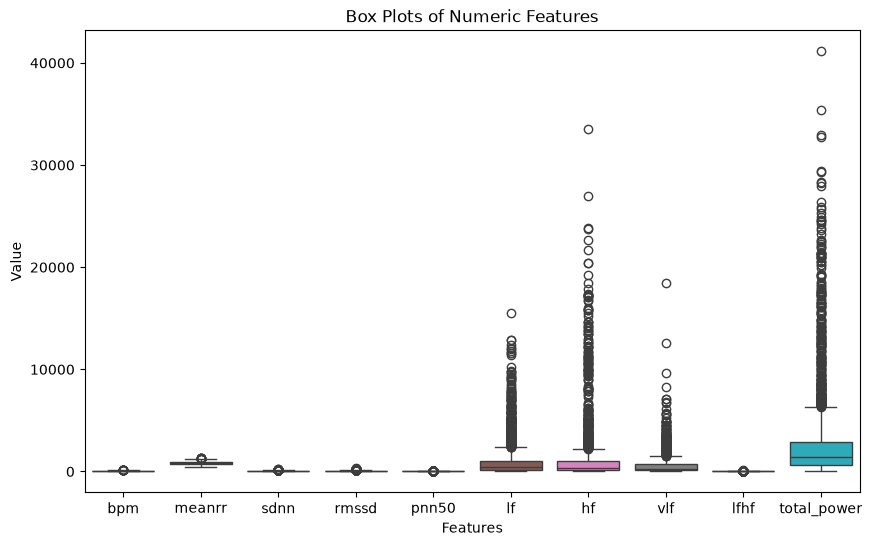

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.show()

The outliers for lf / hf / vlf are huge. We probably need to apply transformation to address that

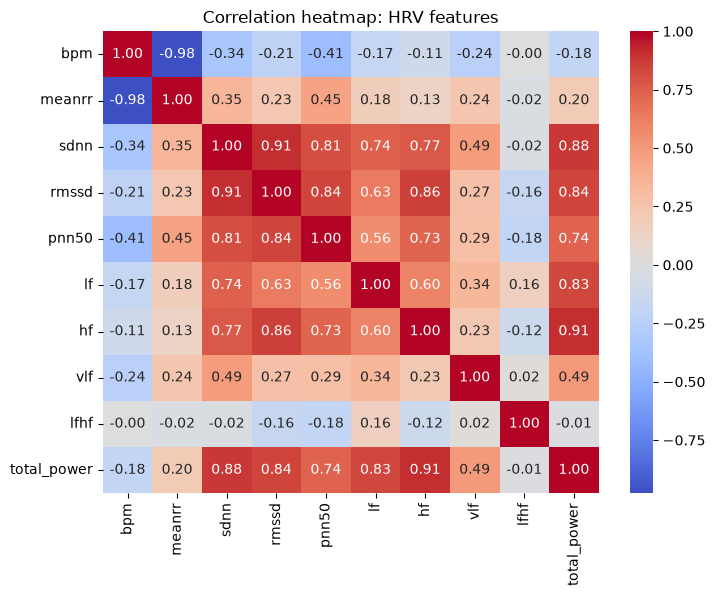

In [17]:
plt.figure(figsize=(8,6))
corr = df[numeric_columns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap: HRV features")
plt.show()


We can see that total_power is highly correlated with multiple fields. We can probably consider removing it for ML

### Data tranformation

In [21]:
df_copy = df.copy()

df_copy.drop(columns=['total_power'], inplace=True)

cols = ["lf", "hf", "vlf"]

scaler = StandardScaler()
scaled_cols = [f"{c}_scaled" for c in cols]
df_copy[scaled_cols] = scaler.fit_transform(df_copy[cols])
print(df_copy[scaled_cols].agg(["mean", "std", "min", "max"]).round(2))

      lf_scaled  hf_scaled  vlf_scaled
mean       0.00      -0.00        0.00
std        1.00       1.00        1.00
min       -0.64      -0.45       -0.66
max       10.03      13.00       20.41


### New feature

We can combine weight and height to create BMI, it's often used in medical examinations

In [ ]:
df["bmi"] = df["weight"] / (df["height"] / 100) ** 2

# sanity-check against a plausible human BMI range instead of trusting it blindly
implausible_bmi = ~df["bmi"].between(12, 60)
print("Implausible BMI rows:", implausible_bmi.sum(), "out of", df["bmi"].notna().sum())

df["bmi"].describe()


Implausible BMI rows: 8 out of 3237


count    3237.000000
mean       27.757654
std         7.480809
min        13.143360
25%        22.185840
50%        26.808163
75%        31.249135
max        54.277185
Name: bmi, dtype: float64

| Dimension | Finding |
|---|---|
| **Profiling** | `participants` is 185 rows × 8 columns, `hrv_measurements` is 3245 rows × 22 columns, merged to 3245 × 29. Several HRV fields (`lf`, `hf`, `vlf`, `lfhf`) show a large gap between mean and median, indicating right-skewed distributions. |
| **Completeness** | `how_sleep` (54.8%), `tags` (32.2%), and `symptoms_onset` (13.2%) have significant missingness; all other fields are under 1%. `how_sleep` was kept as NaN rather than imputed, since it's a subjective survey answer with no reliable way to infer it from other columns. |
| **Accuracy** | No external ground truth exists to validate self-measured, phone-camera-based HRV readings against. As a partial proxy, the engineered `bmi` feature was checked for physiological plausibility (12–60 range) and flagged 8 out of 3237 rows as implausible, showing the data does contain some accuracy issues even in simple derived fields. |
| **Consistency** | HRV measurements come from mixed sources (Bluetooth monitor and phone-camera PPG per the dataset README), which have different noise characteristics for the same true HRV value — a consistency risk the dataset doesn't let us fully verify or correct for. |
| **Integrity** | The merge preserved row count exactly (3245 rows before and after joining `hrv_measurements` to `participants`), confirming the join was many-to-one as expected with no duplication. No exact duplicate rows or duplicate (user_code, measurement_datetime) pairs were found. |
| **Lineage & provenance** | Welltory app → user-consented measurement → Welltory's own proprietary PPG signal-processing pipeline → published to this GitHub repo. The HRV values are already preprocessed before reaching this CSV, so this analysis audits Welltory's transformed output, not the raw PPG signal. |